In [4]:
# 09/02
def pizza_price_model(size):
    weight =2 
    bias = 3
    price = weight * size * bias
    return price

size = 5
predicted_price = pizza_price_model(size)
print(predicted_price)

30


In [5]:
import torch

def forward_pass(x, w, b):
    output = torch.mm(x, w) + b
    return output

x = torch.tensor([[1.0, 2.0],
                 [3.0, 4.0]])
w = torch.tensor([[0.5, -0.5],
                 [1.0, 1.0]])

b = torch.tensor([[1.0, 1.0]])

output = forward_pass(x, w, b)
print(output)

tensor([[3.5000, 2.5000],
        [6.5000, 3.5000]])


In [6]:
import torch
import torch.nn as nn

x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y_true = 2 * x + 1

model_output = torch.tensor([[2.5], [3.5], [4.5], [5.5]])
criterion = nn.MSELoss()

loss = criterion(model_output, y_true) 
print(loss) 

tensor(5.2500)


In [7]:
actual_price = 11
predicted_price = 13

error = predicted_price - actual_price

print(error)

weight = 2
bias = 3
learning_rate = 0.01
weight = weight - learning_rate * error * size
bias = bias - learning_rate * error

price = weight * size + bias
print(price)

2
12.48


In [8]:
x = torch.tensor(2.0, requires_grad=True)

# 순전파
y = x ** 2 + 3 * x + 4
# 역전파
y.backward()
# 기울기
print(x.grad)

tensor(7.)


In [9]:
# loss 구하기
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True)
y = (x ** 2).sum()

y.backward()
print(x.grad)

tensor([[2., 4.],
        [6., 8.]])


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

# 선형 회귀 모델 만들기
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

x = torch.tensor([[1.0], [2.0],
                  [3.0], [4.0]])
y_true = 2 * x + 1

model = LinearRegressionModel(1, 1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    # 순전파
    pred = model(x)
    # loss 계산
    loss = criterion(pred, y_true)
    # 역전파
    loss.backward()
    # 
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(epoch + 1, loss.item())

20 0.040250904858112335
40 0.0005137244006618857
60 0.0004321058513596654
80 0.0003832524816971272
100 0.0003399348061066121


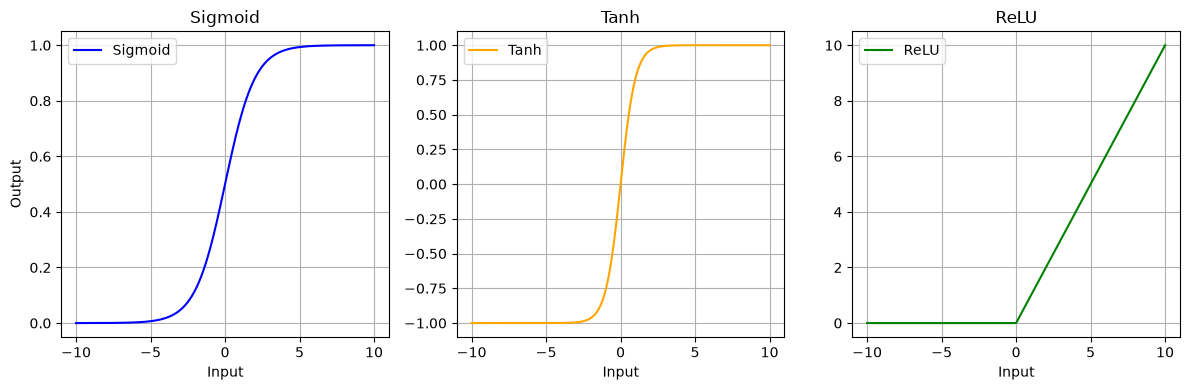

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

y_sigmoid = sigmoid(x)
y_tanh = np.tanh(x)
y_relu = relu(x)


plt.figure(figsize=(12, 4))
# 1) Sigmoid -> 0 ~ 1 값
plt.subplot(1, 3, 1)
plt.plot(x, y_sigmoid, label='Sigmoid', color='blue')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Sigmoid')
plt.grid(True)
plt.legend()

# 2) Tanh -> -1 ~ 1 값
plt.subplot(1, 3, 2)
plt.plot(x, y_tanh, label='Tanh', color='orange')
plt.xlabel('Input')
plt.title('Tanh')
plt.grid(True)
plt.legend()

# 3) ReLU -> 0 ~ 무한대 값
plt.subplot(1, 3, 3)
plt.plot(x, y_relu, label='ReLU', color='green')
plt.xlabel('Input')
plt.title('ReLU')
plt.grid(True)
plt.legend()

# 서브플롯 간 여백 조정
plt.tight_layout()

plt.show()

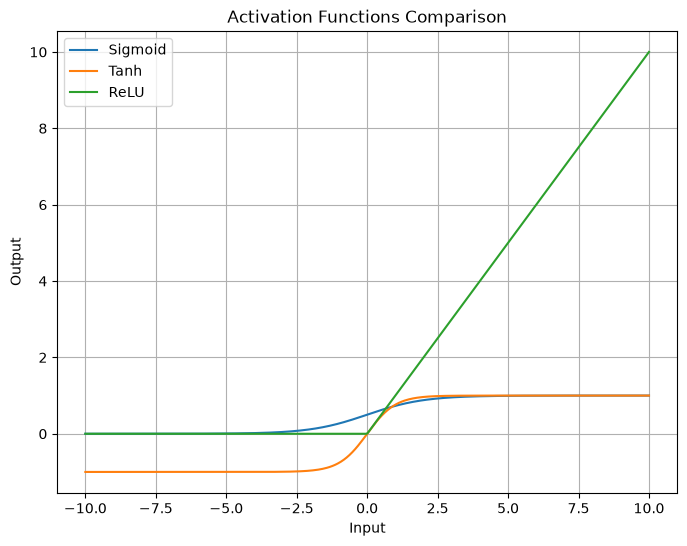

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.plot(x, y_relu, label='ReLU')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Activation Functions Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data',
                               train=True,
                               download=True,
                               transform=transform)

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset,
                          batch_size=64,
                          shuffle=True)
data_iter = iter(train_loader)

images, labels = next(data_iter)
print(images.shape)

torch.Size([64, 1, 28, 28])


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms


class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.fc(x)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data',
                               train=True,
                               download=True,
                               transform=transform)
test_dataset = datasets.MNIST(root='./data',
                               train=False,
                               download=True,
                               transform=transform)

train_loader = DataLoader(train_dataset,
                          batch_size=64,
                          shuffle=True)
test_loader = DataLoader(test_dataset,
                         batch_size=64,
                         shuffle=False)

model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(epoch +1, avg_loss)

def evaluate(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

test_accuracy = evaluate(model, test_loader)
print(test_accuracy)

1 0.2670792728436114
2 0.11309903061517806
3 0.08050414972823423
4 0.06026098976132156
5 0.04796654071228436
97.54


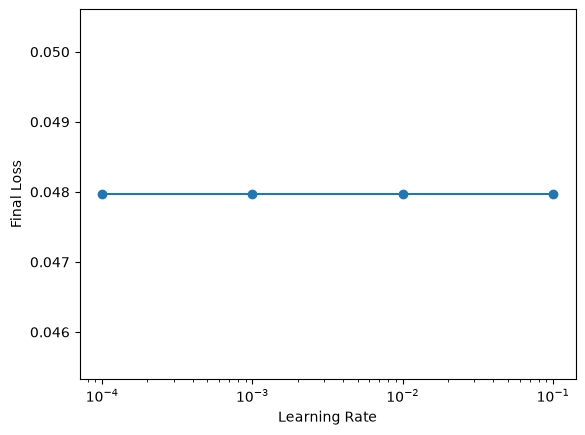

In [17]:
# 하이퍼 파라미터 튜닝

learning_rate = [0.1, 0.01, 0.001, 0.0001]
final_losses = []

for lr in learning_rate:
    model = SimpleMLP()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(10):
        model.train()
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    loss_avg = total_loss / len(train_loader)
    final_losses.append(loss_avg)

plt.plot(learning_rate, final_losses, marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('Final Loss')
plt.xscale('log')
plt.show()

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 10))

    def forward(self, x):
        return self.network(self.flatten(x))

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1037,),(0.3081,))])

train_dataset = datasets.MNIST(root='./data',
                               train=True,
                               download=True,
                               transform=transform)
test_dataset = datasets.MNIST(root='./data',
                               train=False,
                               download=True,
                               transform=transform)

train_loader = DataLoader(train_dataset,
                          batch_size=64,
                          shuffle=True)
test_loader = DataLoader(test_dataset,
                         batch_size=1000,
                         shuffle=False)

In [19]:
model = MNISTNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses = []
model.train()

for _ in range(5):
    running = 0.0
    for data, target in train_loader:
        out = model(data)
        loss = criterion(out, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()
    train_losses.append(running / len(train_loader))

In [30]:
import platform
import matplotlib.pyplot as plt
from matplotlib import font_manager

system = platform.system()
if system == 'Windows':
    # Windows는 맑은 고딕이 기본 내장되어 있어 설치 없이 바로 사용 가능
    plt.rc('font', family='Malgun Gothic')
elif system == 'Darwin':
    # macOS 기본 내장 한글 폰트
    plt.rc('font', family='AppleGothic')
else:
    # Colab 등 Linux: 위 셀에서 설치한 나눔고딕을 등록
    font_dir = '/usr/share/fonts/truetype/nanum'
    font_files = font_manager.findSystemFonts(fontpaths=font_dir)
    for fpath in font_files:
        font_manager.fontManager.addfont(fpath)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

# 설정한 폰트가 실제로 잡혔는지 확인
print('적용된 폰트:', plt.rcParams['font.family'])

적용된 폰트: ['Malgun Gothic']


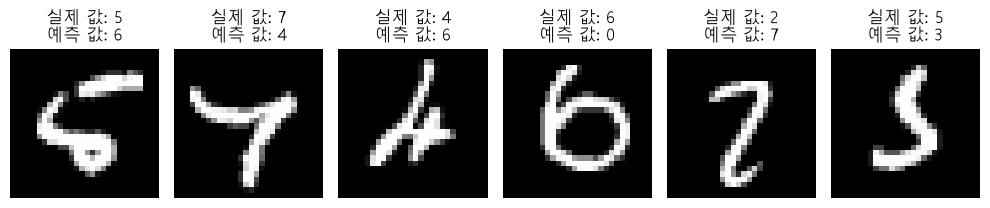

In [34]:
wrong_images, wrong_preds, wrong_targets = [], [], []
model.eval()
with torch.no_grad():
    for data, target in test_loader:
        out = model(data)
        preds = out.argmax(dim=1)
        mask = preds != target
        idxs = mask.nonzero().squeeze()
        for i in idxs:
            if len(wrong_images) >= 6:
                break
            wrong_images.append(data[i])
            wrong_preds.append(preds[i].item())
            wrong_targets.append(target[i].item())

    if len(wrong_images) >= 6:
        pass

plt.figure(figsize=(10,4))
for i in range(len(wrong_images)):
    ax = plt.subplot(1, 6, i+1)
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'실제 값: {wrong_targets[i]}\n예측 값: {wrong_preds[i]}')
plt.tight_layout()
plt.show()

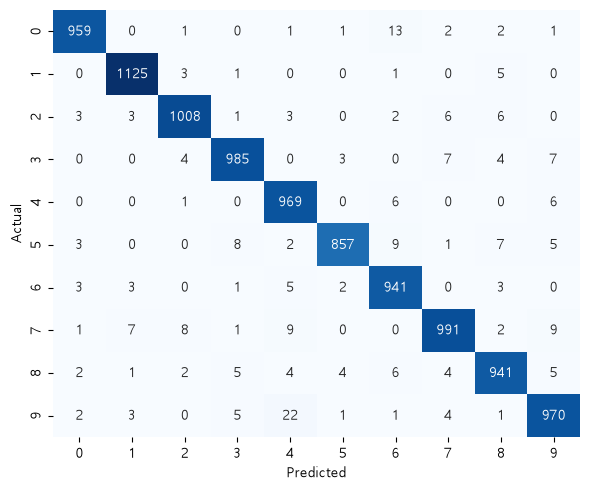

In [40]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        out = model(data)
        all_preds.extend(out.argmax(dim=1).tolist())
        all_labels.extend(target.tolist())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

0, 58.9, 73.24
10, 99.9, 88.55
20, 100.0, 89.21
30, 100.0, 89.13
40, 100.0, 89.13
과적합 점수: 10.9% (훈련-테스트 정확도 차이)
0, 51.9, 73.26
10, 98.5, 88.76
20, 99.1, 85.89
30, 100.0, 89.0
40, 99.6, 88.37
과적합 점수: 13.7% (훈련-테스트 정확도 차이)
0, 27.8, 56.77
10, 93.8, 88.51
20, 96.6, 89.47
30, 97.6, 89.78
40, 98.3, 88.67
과적합 점수: 9.0% (훈련-테스트 정확도 차이)
0, 10.2, 22.06
10, 42.3, 61.61
20, 59.0, 76.79
30, 67.3, 80.74
40, 71.8, 84.24
과적합 점수: -8.3% (훈련-테스트 정확도 차이)


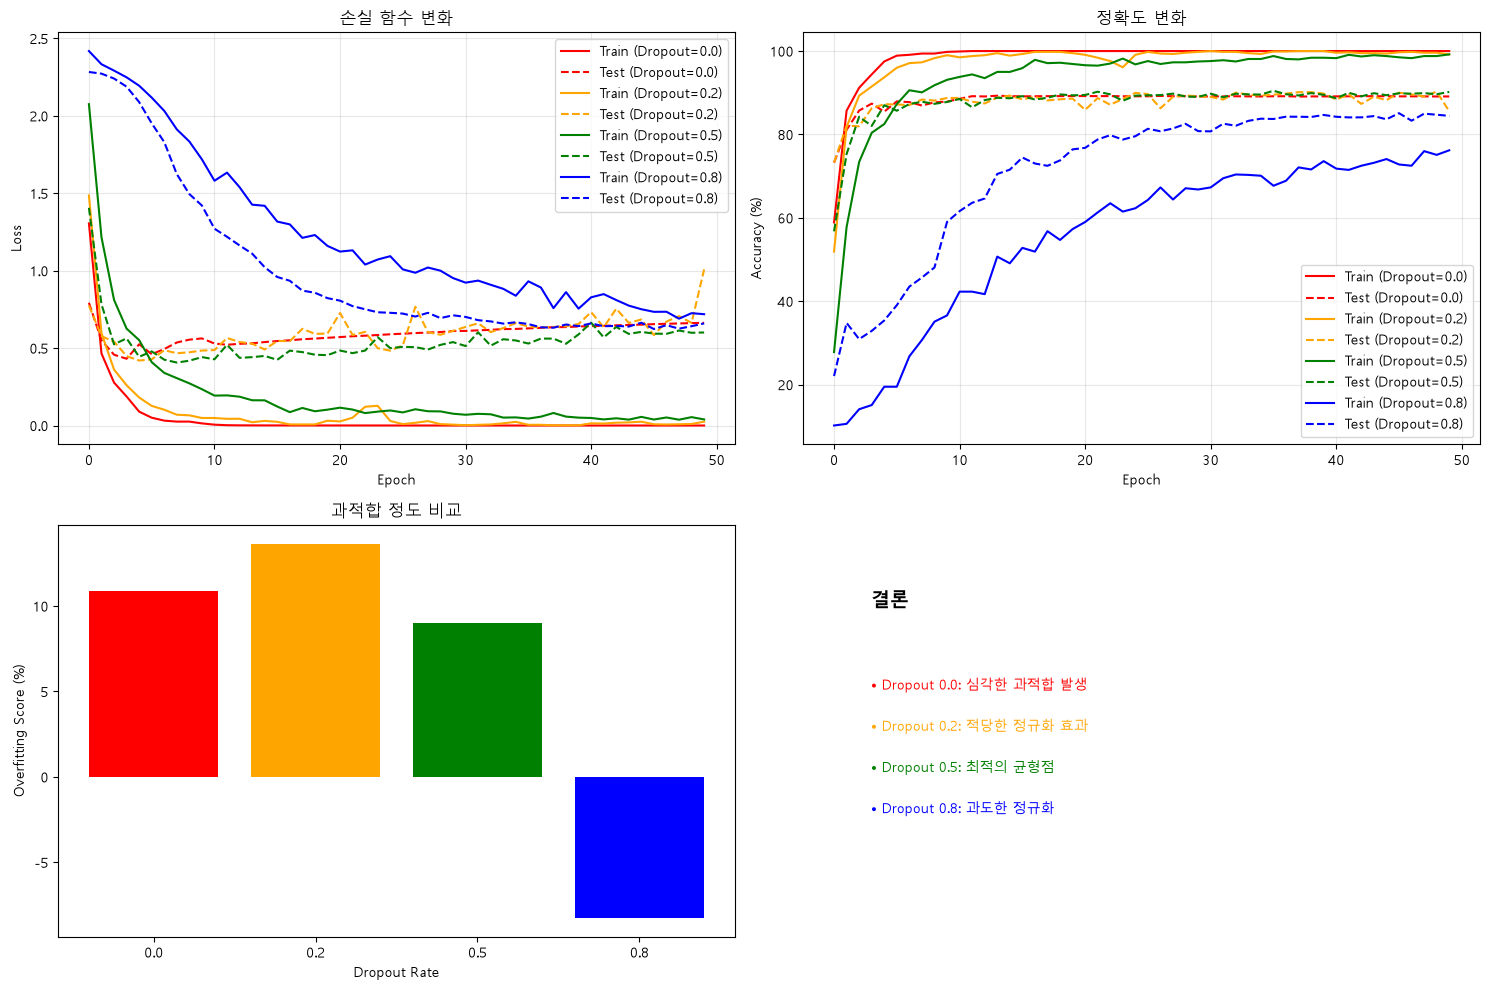


결론:
Dropout 0.5 근처가 최적의 균형점!
너무 낮으면 과적합, 너무 높으면 학습 부족!


In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

def overfitting_detective():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081))
    ])
    train_dataset = datasets.MNIST('./data', train = True, download = True, transform=transform)
    test_dataset = datasets.MNIST('./data', train = False, download = True, transform=transform)

    train_subset = Subset(train_dataset, range(1000))
    train_loader = DataLoader(train_subset, batch_size = 32, shuffle = True)
    test_loader = DataLoader(test_dataset, batch_size = 1000, shuffle = True)

    class OverfittingNet(nn.Module):
        def __init__(self, dropout_rate):
            super().__init__()
            self.flatten = nn.Flatten()
            self.network = nn.Sequential(
                nn.Linear(784, 512),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(128, 10)
            )
        def forward(self, x):
            return self.network(self.flatten(x))

    dropout_rates = [0.0, 0.2, 0.5, 0.8]
    colors = ['red', 'orange', 'green', 'blue']
    overfitting_scores = []

    plt.figure(figsize=(15, 10))

    for i, dropout_rate in enumerate(dropout_rates):
        model = OverfittingNet(dropout_rate)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()

        train_losses, test_losses, train_accuracies, test_accuracies = [], [], [], []

        for epoch in range(50):
            model.train()
            train_loss = 0
            train_correct = 0
            train_total = 0

            for data, target in train_loader:
                optimizer.zero_grad()
                output = model(data)
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                train_total += target.size(0)
                train_correct += (predicted == target).sum().item()

            model.eval()
            test_loss = 0
            test_correct = 0
            test_total = 0

            with torch.no_grad():
                for data, target in test_loader:
                    output = model(data)
                    test_loss += criterion(output, target).item()
                    _, predicted = torch.max(output.data, 1)
                    test_total += target.size(0)
                    test_correct += (predicted == target).sum().item()

            train_losses.append(train_loss / len(train_loader))
            test_losses.append(test_loss / len(test_loader))
            train_accuracies.append(100 * train_correct / train_total)
            test_accuracies.append(100 * test_correct / test_total)

            if epoch % 10 == 0:
                print(f'{epoch}, {train_accuracies[-1]}, {test_accuracies[-1]}')

        plt.subplot(2, 2, 1)
        plt.plot(train_losses, color=colors[i], linestyle='-', label=f'Train (Dropout={dropout_rate})')
        plt.plot(test_losses, color=colors[i], linestyle='--', label=f'Test (Dropout={dropout_rate})')

        plt.subplot(2, 2, 2)
        plt.plot(train_accuracies, color=colors[i], linestyle='-', label=f'Train (Dropout={dropout_rate})')
        plt.plot(test_accuracies, color=colors[i], linestyle='--', label=f'Test (Dropout={dropout_rate})')

        overfitting_score = train_accuracies[-1] - test_accuracies[-1]
        overfitting_scores.append(overfitting_score)
        print(f"과적합 점수: {overfitting_score:.1f}% (훈련-테스트 정확도 차이)")

    plt.rcParams['axes.unicode_minus'] = False
    plt.subplot(2, 2, 1)
    plt.title('손실 함수 변화')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.title('정확도 변화')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    plt.bar(range(len(dropout_rates)), overfitting_scores, color=colors)
    plt.title('과적합 정도 비교')
    plt.xlabel('Dropout Rate')
    plt.ylabel('Overfitting Score (%)')
    plt.xticks(range(len(dropout_rates)), dropout_rates)

    plt.subplot(2, 2, 4)
    plt.text(0.1, 0.8, '결론', fontsize=14, weight='bold')
    conclusions = [
        '• Dropout 0.0: 심각한 과적합 발생',
        '• Dropout 0.2: 적당한 정규화 효과',
        '• Dropout 0.5: 최적의 균형점',
        '• Dropout 0.8: 과도한 정규화'
    ]

    for i, conclusion in enumerate(conclusions):
        plt.text(0.1, 0.6-i*0.1, conclusion, fontsize=10, color=colors[i])

    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("\n결론:")
    print("Dropout 0.5 근처가 최적의 균형점!")
    print("너무 낮으면 과적합, 너무 높으면 학습 부족!")

overfitting_detective()